# Text Generation using SimpleRNN, LSTM and GRU

## Objective

The objective of this project is to build and compare three recurrent neural network architectures—SimpleRNN, LSTM, and GRU—for next-word prediction and text generation. Instead of using the sample corpus, this project uses an English translation of the Bhagavad Gita as the training corpus to evaluate how each architecture learns contextual word sequences.

### Dataset Loading

The Bhagavad Gita corpus is loaded from the Kaggle input directory. The following code verifies the dataset path before it is used for preprocessing and model training.

In [5]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/srisg1701/bhagavad-gita/bhagavad_gita.txt


### Import Libraries

In [6]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import GRU
from tensorflow.keras.layers import Dense

### Dataset Description

The dataset used in this project is an English translation of the **Bhagavad Gita**, *The Song Celestial*, translated by **Sir Edwin Arnold**. This public-domain text was obtained from **Project Gutenberg** and was chosen because it provides a rich, continuous corpus suitable for learning contextual word relationships in a sequence modeling task.

Before training the neural network, the raw text will be preprocessed to remove metadata, normalize formatting, and prepare it for tokenization.

In [7]:
with open("/kaggle/input/datasets/srisg1701/bhagavad-gita/bhagavad_gita.txt", "r", encoding="utf-8") as file:
    corpus = file.read()

print(corpus[:1000])

The Project Gutenberg eBook of The Song Celestial; Or, Bhagavad-Gîtâ (from the Mahâbhârata)
    
This eBook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almost no restrictions
whatsoever. You may copy it, give it away or re-use it under the terms
of the Project Gutenberg License included with this eBook or online
at www.gutenberg.org. If you are not located in the United States,
you will have to check the laws of the country where you are located
before using this eBook.

Title: The Song Celestial; Or, Bhagavad-Gîtâ (from the Mahâbhârata)

Translator: Sir Edwin Arnold


        
Release date: November 1, 2000 [eBook #2388]
                Most recently updated: June 23, 2013

Language: English

Other information and formats: www.gutenberg.org/ebooks/2388

Credits: Produced by J. C. Byers.  HTML version by Al Haines.


*** START OF THE PROJECT GUTENBERG EBOOK THE SONG CELESTIAL; OR, BHAGAVAD-GÎTÂ (FROM THE MAHÂBHÂRATA) ***


#### Observation

The initial portion of the corpus confirms that the text contains the Project Gutenberg header and metadata. These non-content sections will be removed during preprocessing so that only the Bhagavad Gita text is used for training.

### Data Preprocessing

In [8]:
start = corpus.find("CHAPTER I")
end = corpus.find("*** END OF THE PROJECT GUTENBERG EBOOK")

if start != -1:
    if end != -1:
        corpus = corpus[start:end]
    else:
        corpus = corpus[start:]

print(corpus[:1000])

CHAPTER I


  Dhritirashtra:
  Ranged thus for battle on the sacred plain--
  On Kurukshetra--say, Sanjaya! say
  What wrought my people, and the Pandavas?

  Sanjaya:
  When he beheld the host of Pandavas,
  Raja Duryodhana to Drona drew,
  And spake these words: "Ah, Guru! see this line,
  How vast it is of Pandu fighting-men,
  Embattled by the son of Drupada,
  Thy scholar in the war! Therein stand ranked
  Chiefs like Arjuna, like to Bhima chiefs,
  Benders of bows; Virata, Yuyudhan,
  Drupada, eminent upon his car,
  Dhrishtaket, Chekitan, Kasi's stout lord,
  Purujit, Kuntibhoj, and Saivya,
  With Yudhamanyu, and Uttamauj
  Subhadra's child; and Drupadi's;-all famed!
  All mounted on their shining chariots!
  On our side, too,--thou best of Brahmans! see
  Excellent chiefs, commanders of my line,
  Whose names I joy to count: thyself the first,
  Then Bhishma, Karna, Kripa fierce in fight,
  Vikarna, Aswatthaman; next to these
  Strong Saumadatti, with full many more
  Valiant a

### Tokenization

Since neural networks cannot understand raw text directly, the cleaned corpus is tokenized using Keras' `Tokenizer`.

- Every unique word is assigned a unique integer index.
- The text is then represented as sequences of numbers instead of words.
- These numerical sequences are used for training the text generation models.

In [9]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

vocab_size = len(tokenizer.word_index) + 1
print("Vocabulary Size:", vocab_size)

Vocabulary Size: 3572


In [10]:
for word, index in list(tokenizer.word_index.items())[:20]:
    print(f"{word}: {index}")

the: 1
and: 2
of: 3
to: 4
in: 5
is: 6
all: 7
i: 8
me: 9
that: 10
with: 11
by: 12
who: 13
not: 14
which: 15
he: 16
for: 17
thou: 18
from: 19
this: 20


### Sequence Generation

The cleaned text is converted into numerical sequences and then used to generate training samples.

- Each word is replaced with its corresponding integer index.
- Multiple n-gram sequences are created by progressively adding one word at a time.
- These sequences will later be split into input features and target labels for next-word prediction.

In [11]:
input_sequences = []

for line in corpus.split("\n"):
    token_list = tokenizer.texts_to_sequences([line])[0]

    if len(token_list) < 2:
        continue

    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i + 1]
        input_sequences.append(n_gram_sequence)

print("Total Input Sequences:", len(input_sequences))
print(input_sequences[:3])

Total Input Sequences: 17064
[[78, 8], [1063, 79], [1063, 79, 17]]


### Sequence Padding

The generated input sequences have different lengths, but neural networks require inputs of the same size.

- The maximum sequence length is identified.
- Shorter sequences are padded with zeros at the beginning (`pre` padding).
- This ensures that all input sequences have a uniform length before training.

In [12]:
max_sequence_len = max(len(seq) for seq in input_sequences)

input_sequences = pad_sequences(
    input_sequences,
    maxlen=max_sequence_len,
    padding="pre"
)

print("Max Sequence Length:", max_sequence_len)
print(input_sequences.shape)

Max Sequence Length: 14
(17064, 14)


In [13]:
for seq in input_sequences[:5]:
    print(seq)

[ 0  0  0  0  0  0  0  0  0  0  0  0 78  8]
[   0    0    0    0    0    0    0    0    0    0    0    0 1063   79]
[   0    0    0    0    0    0    0    0    0    0    0 1063   79   17]
[   0    0    0    0    0    0    0    0    0    0 1063   79   17  373]
[   0    0    0    0    0    0    0    0    0 1063   79   17  373   36]


### Creating Input Features and Target Labels

The padded sequences are now split into input features and target labels for training the models.

- The input features (`X`) contain all words except the last word in each sequence.
- The target labels (`y`) contain the final word of each sequence.
- During training, the model learns to predict the target word from the preceding input words.

In [14]:
X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (17064, 13)
y Shape: (17064,)


## SimpleRNN Model

The SimpleRNN model is implemented as the baseline model for next-word prediction.

- The Embedding layer learns a dense representation of each word.
- The SimpleRNN layer captures sequential patterns in the text.
- The Dense output layer with softmax activation predicts the most likely next word from the vocabulary.

In [15]:
rnn_model = Sequential()

rnn_model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=50
    )
)

rnn_model.add(SimpleRNN(64))
rnn_model.add(Dense(vocab_size, activation="softmax"))

I0000 00:00:1784538472.151714      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784538472.154526      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [16]:
rnn_model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

In [17]:
rnn_model.build(input_shape=(None, X.shape[1]))
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 13, 50)         │       178,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         7,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3572)           │       232,180 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 418,140 (1.60 MB)

 Trainable params: 418,140 (1.60 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
rnn_history = rnn_model.fit(
    X,
    y,
    epochs=100,
    verbose=1
)

print("Vanilla RNN training completed")

Epoch 1/100
 49/534 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0120 - loss: 7.9740

I0000 00:00:1784538477.366370     151 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


534/534 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.0473 - loss: 6.9200
Epoch 2/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.0622 - loss: 6.4495
Epoch 3/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.0770 - loss: 6.1936
Epoch 4/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.0918 - loss: 5.9230
Epoch 5/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1024 - loss: 5.6604
Epoch 6/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1133 - loss: 5.4132
Epoch 7/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1273 - loss: 5.1842
Epoch 8/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1423 - loss: 4.9629
Epoch 9/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1572 - loss: 4.7546
Epoch 10/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1793 - loss: 4.5517
Epoch 11/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.2045 - loss: 4.3555
Epoch 12/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

## LSTM Model

The LSTM model is implemented to learn long-term dependencies in the text for next-word prediction.

- The Embedding layer learns a dense representation of each word.
- The LSTM layer captures contextual information from previous words using its memory cells.
- The Dense output layer with softmax activation predicts the most likely next word from the vocabulary.

In [19]:
lstm_model = Sequential()

lstm_model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=50
    )
)
lstm_model.add(LSTM(64))
lstm_model.add(Dense(vocab_size, activation="softmax"))

In [20]:
lstm_model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

In [21]:
lstm_model.build(input_shape=(None, X.shape[1]))
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 13, 50)         │       178,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3572)           │       232,180 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 440,220 (1.68 MB)

 Trainable params: 440,220 (1.68 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
lstm_history = lstm_model.fit(
    X,
    y,
    epochs=100,
    verbose=1
)

print("LSTM training completed")

Epoch 1/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.0408 - loss: 6.9306
Epoch 2/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.0495 - loss: 6.5319
Epoch 3/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.0582 - loss: 6.4540
Epoch 4/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.0615 - loss: 6.3798
Epoch 5/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.0673 - loss: 6.2863
Epoch 6/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.0745 - loss: 6.1691
Epoch 7/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.0833 - loss: 6.0384
Epoch 8/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.0891 - loss: 5.9123
Epoch 9/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.0948 - loss: 5.7933
Epoch 10/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.1028 - loss: 5.6807
Epoch 11/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.1096 - loss: 5.5719
Epoch 12/100
534/534 ━━━━━━━━━━━━━━━━━━━━

## GRU Model

The GRU model is implemented as an alternative recurrent architecture for next-word prediction.

- The Embedding layer learns a dense representation of each word.
- The GRU layer captures sequential information using a simpler gating mechanism.
- The Dense output layer with softmax activation predicts the most likely next word from the vocabulary.

In [23]:
gru_model = Sequential()

gru_model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=50
    )
)

gru_model.add(GRU(64))
gru_model.add(Dense(vocab_size, activation="softmax"))

In [24]:
gru_model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

In [25]:
gru_model.build(input_shape=(None, X.shape[1]))
gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 13, 50)         │       178,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        22,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3572)           │       232,180 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 433,052 (1.65 MB)

 Trainable params: 433,052 (1.65 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
gru_history = gru_model.fit(
    X,
    y,
    epochs=100,
    verbose=1
)
print("GRU training completed")

Epoch 1/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.0447 - loss: 6.9443
Epoch 2/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.0576 - loss: 6.4698
Epoch 3/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.0686 - loss: 6.2535
Epoch 4/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.0836 - loss: 6.0273
Epoch 5/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.0968 - loss: 5.7992
Epoch 6/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.1041 - loss: 5.5891
Epoch 7/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.1140 - loss: 5.3930
Epoch 8/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.1218 - loss: 5.2033
Epoch 9/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.1310 - loss: 5.0188
Epoch 10/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.1422 - loss: 4.8416
Epoch 11/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.1570 - loss: 4.6694
Epoch 12/100
534/534 ━━━━━━━━━━━━━━━━━━━━

### Training Loss Comparison

The training loss of the Vanilla RNN, LSTM, and GRU models is compared to evaluate how each model learns during training.

- Training loss is recorded over 100 epochs for all three models.
- Comparing the loss curves helps visualize the convergence behavior of each architecture.
- Lower training loss generally indicates a better fit to the training data.

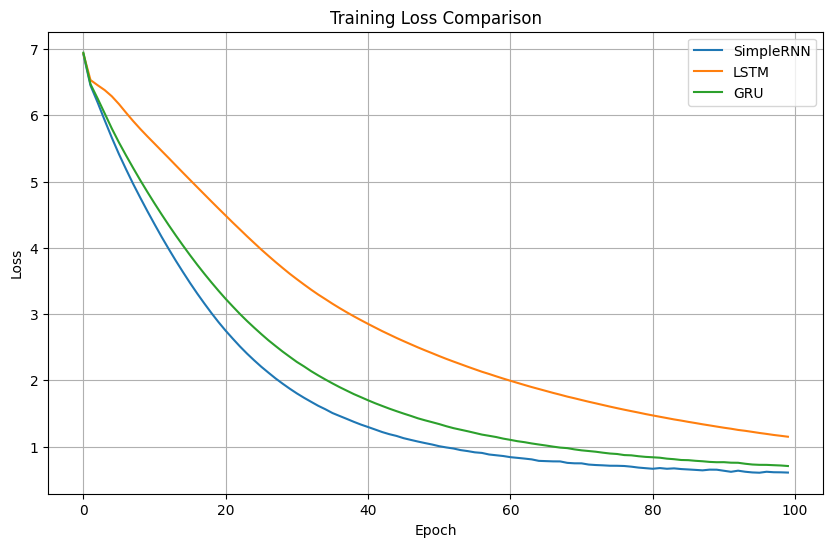

In [27]:
plt.figure(figsize=(10, 6))
plt.plot(rnn_history.history['loss'], label='SimpleRNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')

plt.title('Training Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

### Observation

The training loss decreases steadily for all three models, indicating that each model successfully learns patterns from the training data.

- The Vanilla RNN shows the fastest reduction in training loss and achieves the lowest final loss.
- The GRU also converges well and performs comparably to the Vanilla RNN.
- The LSTM converges more slowly and retains a relatively higher training loss under the current configuration.

### Text Generation

After training the models, a text generation function is created to predict the next word based on a given seed text.

- The function takes a trained model and an initial seed text as input.
- At each step, the model predicts the most probable next word.
- The predicted word is appended to the input sequence to generate a continuous text.

In [28]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]

        token_list = pad_sequences(
            [token_list],
            maxlen=max_sequence_len - 1,
            padding="pre"
        )

        predicted = np.argmax(
            model.predict(token_list, verbose=0),
            axis=-1
        )[0]

        output_word = ""

        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break

        seed_text += " " + output_word

    return seed_text

### Text Generation Results

The trained models are evaluated by generating text from different seed phrases.

- The same seed text is provided to each model for a fair comparison.
- Each model predicts the next five words based on the learned patterns.
- The generated outputs are compared to observe the differences in next-word prediction.

In [29]:
seed = "when he beheld"

print("RNN :", generate_text(rnn_model, seed, 5))
print("LSTM:", generate_text(lstm_model, seed, 5))
print("GRU :", generate_text(gru_model, seed, 5))

RNN : when he beheld the host of pandavas whose
LSTM: when he beheld the host of pandavas o
GRU : when he beheld the host of pandavas in


In [30]:
seed = "on kurukshetra"

print("RNN :", generate_text(rnn_model, seed, 5))
print("LSTM:", generate_text(lstm_model, seed, 5))
print("GRU :", generate_text(gru_model, seed, 5))

RNN : on kurukshetra say sanjaya say he is
LSTM: on kurukshetra say sanjaya say to me
GRU : on kurukshetra say sanjaya say i say


### Observation

All three models successfully generate text using the provided seed phrases.

- The generated sequences follow the vocabulary and writing style of the Bhagavad Gita corpus.
- Different recurrent architectures produce slightly different continuations for the same seed text.
- Although some generated phrases are not grammatically perfect, the models capture meaningful contextual patterns from the training data.

## Improved Models

To evaluate the impact of increasing model capacity, the baseline models are retrained with updated hyperparameters while keeping the preprocessing pipeline and training configuration unchanged.

The following changes are applied to all three models:

- Embedding Dimension = **100**
- Hidden Units = **128**
- Epochs = **200**

### Updated Hyperparameters

The following hyperparameters are used to train the improved versions of the Vanilla RNN, LSTM, and GRU models.

In [31]:
embedding_dim = 100
hidden_units = 128
epochs = 200

## Improved Vanilla RNN Model

In [32]:
improved_rnn_model = Sequential()

improved_rnn_model.add(
    Embedding(input_dim=vocab_size,
              output_dim=embedding_dim)
)
improved_rnn_model.add(SimpleRNN(hidden_units))
improved_rnn_model.add(
    Dense(vocab_size, activation="softmax")
)

improved_rnn_model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

improved_rnn_model.build(input_shape=(None, X.shape[1]))
improved_rnn_model.summary()

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 13, 100)        │       357,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 128)            │        29,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3572)           │       460,788 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 847,300 (3.23 MB)

 Trainable params: 847,300 (3.23 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
improved_rnn_history = improved_rnn_model.fit(
    X,
    y,
    epochs=epochs,
    verbose=1
)

Epoch 1/200
534/534 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.0502 - loss: 6.8991
Epoch 2/200
534/534 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.0719 - loss: 6.3575
Epoch 3/200
534/534 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.0942 - loss: 5.9130
Epoch 4/200
534/534 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1162 - loss: 5.4505
Epoch 5/200
534/534 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1422 - loss: 5.0072
Epoch 6/200
534/534 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1797 - loss: 4.5794
Epoch 7/200
534/534 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.2310 - loss: 4.1707
Epoch 8/200
534/534 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.2866 - loss: 3.7877
Epoch 9/200
534/534 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3497 - loss: 3.4234
Epoch 10/200
534/534 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4111 - loss: 3.0887
Epoch 11/200
534/534 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4638 - loss: 2.7845
Epoch 12/200
534/534 ━━━━━━━━━━━━━━━━━━━━

## Improved LSTM Model

In [35]:
improved_lstm_model = Sequential()

improved_lstm_model.add(
    Embedding(input_dim=vocab_size,
              output_dim=embedding_dim)
)
improved_lstm_model.add(LSTM(hidden_units))
improved_lstm_model.add(
    Dense(vocab_size, activation="softmax")
)

improved_lstm_model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

improved_lstm_model.build(input_shape=(None, X.shape[1]))
improved_lstm_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 13, 100)        │       357,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 128)            │       117,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3572)           │       460,788 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 935,236 (3.57 MB)

 Trainable params: 935,236 (3.57 MB)

 Non-trainable params: 0 (0.00 B)

In [36]:
improved_lstm_history = improved_lstm_model.fit(
    X,
    y,
    epochs=epochs,
    verbose=1
)

Epoch 1/200
534/534 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.0464 - loss: 6.9169
Epoch 2/200
534/534 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.0557 - loss: 6.5207
Epoch 3/200
534/534 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.0663 - loss: 6.3773
Epoch 4/200
534/534 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.0748 - loss: 6.1925
Epoch 5/200
534/534 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.0868 - loss: 5.9810
Epoch 6/200
534/534 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.1011 - loss: 5.7517
Epoch 7/200
534/534 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.1110 - loss: 5.5195
Epoch 8/200
534/534 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.1217 - loss: 5.2889
Epoch 9/200
534/534 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.1325 - loss: 5.0649
Epoch 10/200
534/534 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.1443 - loss: 4.8464
Epoch 11/200
534/534 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.1615 - loss: 4.6305
Epoch 12/200
534/534 ━━━━━━━━━━━━━━━━━━━━

## Improved GRU Model

In [37]:
improved_gru_model = Sequential()

improved_gru_model.add(
    Embedding(input_dim=vocab_size,
              output_dim=embedding_dim)
)
improved_gru_model.add(GRU(hidden_units))
improved_gru_model.add(
    Dense(vocab_size, activation="softmax")
)

improved_gru_model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

improved_gru_model.build(input_shape=(None, X.shape[1]))
improved_gru_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 13, 100)        │       357,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 128)            │        88,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3572)           │       460,788 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 906,308 (3.46 MB)

 Trainable params: 906,308 (3.46 MB)

 Non-trainable params: 0 (0.00 B)

In [38]:
improved_gru_history = improved_gru_model.fit(
    X,
    y,
    epochs=epochs,
    verbose=1
)

Epoch 1/200
534/534 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.0476 - loss: 6.9411
Epoch 2/200
534/534 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.0667 - loss: 6.3675
Epoch 3/200
534/534 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.0919 - loss: 6.0129
Epoch 4/200
534/534 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.1075 - loss: 5.6494
Epoch 5/200
534/534 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.1261 - loss: 5.2660
Epoch 6/200
534/534 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.1451 - loss: 4.8741
Epoch 7/200
534/534 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.1788 - loss: 4.4878
Epoch 8/200
534/534 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.2161 - loss: 4.1170
Epoch 9/200
534/534 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.2687 - loss: 3.7650
Epoch 10/200
534/534 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3230 - loss: 3.4391
Epoch 11/200
534/534 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3745 - loss: 3.1395
Epoch 12/200
534/534 ━━━━━━━━━━━━━━━━━━━━

### Training Loss Comparison (Improved Models)

The training loss of the improved Vanilla RNN, LSTM, and GRU models is compared to evaluate the impact of the updated hyperparameters.

- All three models are trained using the same improved configuration.
- The loss curves show how each model converges over 200 training epochs.
- The results are compared to understand the learning behavior of each improved architecture.

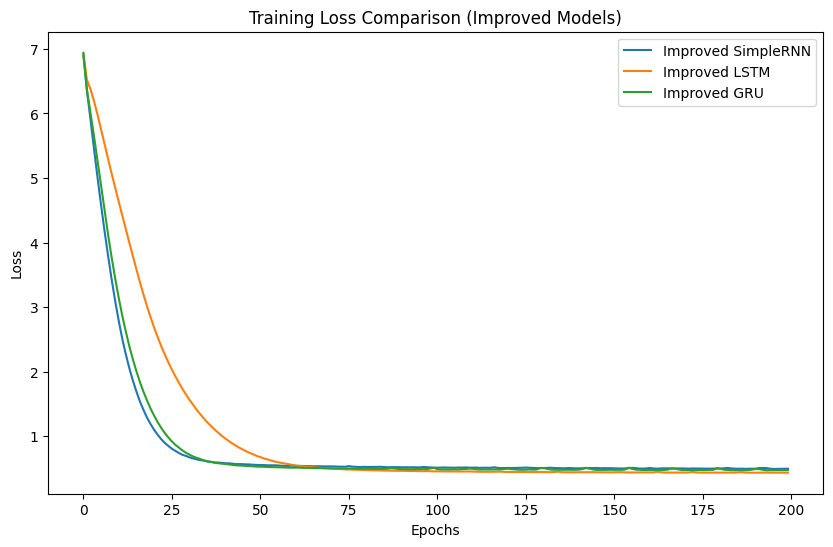

In [39]:
plt.figure(figsize=(10,6))

plt.plot(improved_rnn_history.history["loss"], label="Improved SimpleRNN")
plt.plot(improved_lstm_history.history["loss"], label="Improved LSTM")
plt.plot(improved_gru_history.history["loss"], label="Improved GRU")

plt.title("Training Loss Comparison (Improved Models)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

### Observation

The training loss decreases rapidly during the initial epochs and gradually stabilizes for all three improved models, indicating successful convergence.

- The improved models achieve lower and more stable training losses than their baseline counterparts.
- The Improved SimpleRNN and Improved GRU converge faster, while the Improved LSTM also reaches a similar loss after additional training.
- By the end of training, the loss curves of all three models become very close, suggesting that the updated hyperparameters significantly improve the learning performance of each architecture.

## Improved Text Generation Results

The improved models are evaluated using the same seed phrase to observe the effect of the updated hyperparameters on text generation.

- Each model generates the next **10 words** from the given seed text.
- Using the same seed allows a fair comparison between the improved models.
- The generated outputs are compared to evaluate contextual continuity and coherence.

In [40]:
seed = "when he beheld"

print("Improved RNN :",
      generate_text(improved_rnn_model, seed, 10))

print("Improved LSTM:",
      generate_text(improved_lstm_model, seed, 10))

print("Improved GRU :",
      generate_text(improved_gru_model, seed, 10))

Improved RNN : when he beheld the host of pandavas all things change of little minds
Improved LSTM: when he beheld the host of pandavas whose feet are set thee seeing
Improved GRU : when he beheld the host of pandavas comes not them to do the


### Observation

The improved models generate longer text sequences while maintaining the context of the given seed phrase.

- All three models successfully continue the input using vocabulary learned from the Bhagavad Gita corpus.
- The generated sequences show better contextual continuity than the baseline models.
- Although the sentences are not always grammatically complete, the improved models produce more meaningful and coherent word sequences.

In [42]:
print("Vanilla RNN Loss      :", rnn_history.history["loss"][-1])
print("LSTM Loss             :", lstm_history.history["loss"][-1])
print("GRU Loss              :", gru_history.history["loss"][-1])

print("Improved RNN Loss     :", improved_rnn_history.history["loss"][-1])
print("Improved LSTM Loss    :", improved_lstm_history.history["loss"][-1])
print("Improved GRU Loss     :", improved_gru_history.history["loss"][-1])

Vanilla RNN Loss      : 0.6067622303962708
LSTM Loss             : 1.1479352712631226
GRU Loss              : 0.7057207226753235
Improved RNN Loss     : 0.49833691120147705
Improved LSTM Loss    : 0.4363689720630646
Improved GRU Loss     : 0.4767363667488098


## Model Comparison

The following table summarizes the baseline and improved models based on their architecture, training configuration, and training performance.

| Model | Embedding Dimension | Hidden Units | Epochs | Final Training Loss | Generated Words |
|:------|:-------------------:|:------------:|:------:|:-------------------:|:---------------:|
| Vanilla RNN | 50 | 64 | 100 | **0.6068** | 5 |
| LSTM | 50 | 64 | 100 | **1.1479** | 5 |
| GRU | 50 | 64 | 100 | **0.7057** | 5 |
| Improved Vanilla RNN | 100 | 128 | 200 | **0.4983** | 10 |
| Improved LSTM | 100 | 128 | 200 | **0.4364** | 10 |
| Improved GRU | 100 | 128 | 200 | **0.4767** | 10 |

### Summary

- Increasing the embedding dimension, hidden units, and training epochs reduced the training loss for all three models.
- The improved models produced more coherent and context-aware text generation than the baseline models.
- Among the improved models, the LSTM achieved the lowest final training loss, while all three architectures demonstrated better convergence than their baseline counterparts.

## Conclusion

In this project, next-word prediction models based on Vanilla RNN, LSTM, and GRU were developed using the English translation of the Bhagavad Gita as the training corpus. The text was preprocessed, tokenized, converted into n-gram sequences, and used to train recurrent neural network models for sequence prediction and text generation.

The baseline models successfully learned sequential word relationships and generated context-aware text. Increasing the embedding dimension, hidden units, and training epochs improved the learning capability of all three models, resulting in lower training loss and more coherent text generation. Among the improved models, the LSTM achieved the lowest final training loss, while all three architectures demonstrated better convergence than their baseline counterparts.

Overall, this project demonstrates the effectiveness of recurrent neural networks for next-word prediction and highlights the impact of hyperparameter tuning on improving model performance for natural language processing tasks.